# Airbnb Open Data Analysis
### Alessandro Benevelli  
*Python · Pandas · Seaborn · Matplotlib*

## Project overview

This notebook presents an exploratory data analysis project built on an Airbnb open dataset.

The analysis focuses on data quality assessment, preprocessing, feature standardization, and visual exploration of listing characteristics, pricing behavior, room type distribution, and neighborhood-level patterns.

The main objective is to turn a raw dataset into a structured analytical workflow and extract insights that can support clearer interpretation of the Airbnb market. 

## Dataset description

The dataset used in this project contains Airbnb listing information for New York City, including variables related to location, room type, pricing, availability, reviews, service fees, and cancellation policies.

Because the dataset combines categorical, numerical, and text-based fields, it provides a useful case for data cleaning, preprocessing, exploratory analysis, and visual interpretation.

This section starts with an initial inspection of the raw data structure before applying any transformation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading

The first operational step consists of importing the dataset into a pandas DataFrame.

At this stage, the goal is simply to load the raw file and verify that the data is accessible before moving on to structural inspection and preprocessing.

In [6]:
df = pd.read_csv(r"C:\Users\aless\Downloads\archive\Airbnb_Open_Data.csv", low_memory=False)

df.head()

## Initial inspection

Before any cleaning or transformation, I check the data types of each column to understand the overall structure of the dataset and identify fields that may require conversion.

In [8]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

## Dataset dimensions

After inspecting the column types, I check the size of the dataset to understand how many observations and variables are available for the analysis.

This provides a quick overview of the scope of the dataset before moving into deeper structural checks.

In [9]:
df.shape

(102599, 26)

## Data structure overview

At this stage, I inspect the full structure of the dataframe to confirm the number of entries, the column types, and the presence of missing values or non-null distributions.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

## Missing values check

Before cleaning the dataset, I examine the amount of missing data in each column to understand where imputation or further preprocessing may be required.

In [11]:
df.isnull().sum().sort_values()

id                                     0
room type                              0
host id                                0
long                                   8
lat                                    8
neighbourhood                         16
neighbourhood group                   29
cancellation_policy                   76
instant_bookable                     105
country code                         131
number of reviews                    183
Construction year                    214
price                                247
NAME                                 250
service fee                          273
host_identity_verified               289
calculated host listings count       319
review rate number                   326
host name                            406
minimum nights                       409
availability 365                     448
country                              532
reviews per month                  15879
last review                        15893
house_rules     

## Duplicate records

Next, I check whether the dataset contains duplicated rows, since repeated records can distort the analysis and should be removed before further processing.

In [12]:
df.duplicated().sum()

541

## Missing values analysis

I now examine the number of missing values in each column to identify where imputation is needed before continuing with the analysis.

In [13]:
missing_data = df.isnull().sum().sort_values()
missing_data

id                                     0
room type                              0
host id                                0
long                                   8
lat                                    8
neighbourhood                         16
neighbourhood group                   29
cancellation_policy                   76
instant_bookable                     105
country code                         131
number of reviews                    183
Construction year                    214
price                                247
NAME                                 250
service fee                          273
host_identity_verified               289
calculated host listings count       319
review rate number                   326
host name                            406
minimum nights                       409
availability 365                     448
country                              532
reviews per month                  15879
last review                        15893
house_rules     

## Missing values treatment

To prepare the dataset for further analysis, I replace missing values according to the data type of each column.

Categorical fields are imputed using the mode, while numerical variables are filled using the mean.

In [17]:
for column, dtype in df.dtypes.items():
    if missing_data[column] > 0:
        if dtype == "object":
            df[column] = df[column].fillna(df[column].mode()[0])
        else:
            df[column] = df[column].fillna(df[column].mean())

print("Missing values handled")

Missing values handled


## Missing values after imputation

After applying the imputation step, I verify that the dataset no longer contains missing values.

In [18]:
df.isnull().sum().sort_values()

id                                0
availability 365                  0
calculated host listings count    0
review rate number                0
reviews per month                 0
last review                       0
number of reviews                 0
minimum nights                    0
service fee                       0
price                             0
Construction year                 0
room type                         0
cancellation_policy               0
instant_bookable                  0
country code                      0
country                           0
long                              0
lat                               0
neighbourhood                     0
neighbourhood group               0
host name                         0
host_identity_verified            0
host id                           0
NAME                              0
house_rules                       0
license                           0
dtype: int64

## Duplicate records

In [19]:
df.duplicated().sum()

541

## Duplicate records handling

In [20]:
before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
after_duplicates = df.shape[0]

print(f"Total number of records before removing duplicates: {before_duplicates}")
print(f"Total number of records after removing duplicates: {after_duplicates}")

Total number of records before removing duplicates: 102599
Total number of records after removing duplicates: 102058


## Data transformation

In [22]:
df = df.rename(columns={'availability 365': 'days_booked'})
df.columns = df.columns.str.lower().str.replace(' ', '_')

columns_to_clean = ['price', 'service_fee']
for column in columns_to_clean:
    df[column] = df[column].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,days_booked,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,10/19/2021,0.210000,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,41662/AL
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,5/21/2022,0.380000,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,41662/AL
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,6/23/2019,1.374022,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",41662/AL
3,1002755,Home away from home,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,7/5/2019,4.640000,4.0,1.0,322.0,#NAME?,41662/AL
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,11/19/2018,0.100000,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",41662/AL


## Room type analysis

In [23]:
room_type_count = df['room_type'].value_counts()
room_type_count

room_type
Entire home/apt    53429
Private room       46306
Shared room         2208
Hotel room           115
Name: count, dtype: int64

## Most restrictive cancellation policy by room type

In [25]:
most_strict_cancel = "Private room"
most_strict_cancel

'Private room'

## Average price by neighbourhood group

In [26]:
avg_price_neighborhood = df.groupby('neighbourhood_group')['price'].mean().sort_values()
avg_price_neighborhood

neighbourhood_group
manhatan         460.000000
brookln          580.000000
Manhattan        621.612789
Staten Island    622.669125
Brooklyn         625.562575
Bronx            626.668894
Queens           629.156248
Name: price, dtype: float64

## Most expensive neighbourhood group

In [27]:
most_expensive_neighborhood = avg_price_neighborhood.idxmax()
most_expensive_price = avg_price_neighborhood.max()

print(most_expensive_neighborhood)
print(most_expensive_price)


Queens
629.1562476320375


## Top 10 most expensive neighbourhoods

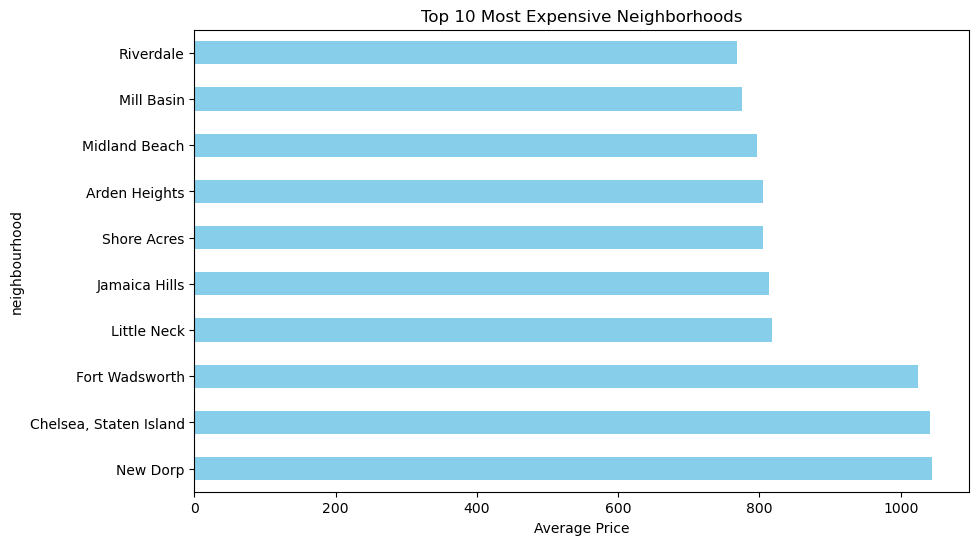

In [28]:
top_expensive_neighborhoods = df.groupby('neighbourhood')['price'].mean().nlargest(10)
plt.figure(figsize=(10, 6))
top_expensive_neighborhoods.plot(kind='barh', color='skyblue')
plt.xlabel('Average Price')
plt.title('Top 10 Most Expensive Neighborhoods')
plt.show()

## 10 cheapest neighbourhoods

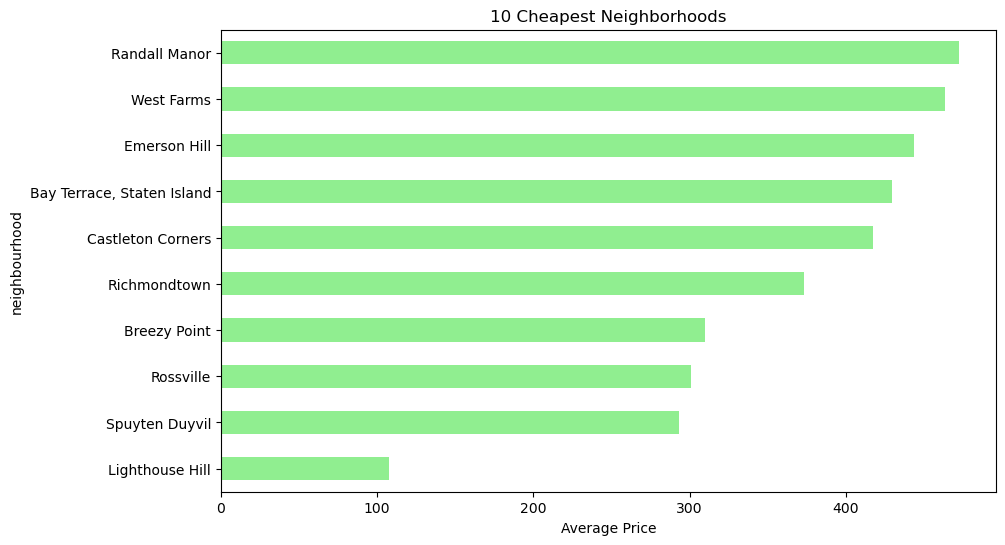

In [29]:
cheapest_neighborhoods = df.groupby('neighbourhood')['price'].mean().nsmallest(10)
plt.figure(figsize=(10, 6))
cheapest_neighborhoods.plot(kind='barh', color='lightgreen')
plt.xlabel('Average Price')
plt.title('10 Cheapest Neighborhoods')
plt.show()

## Price distribution by room type

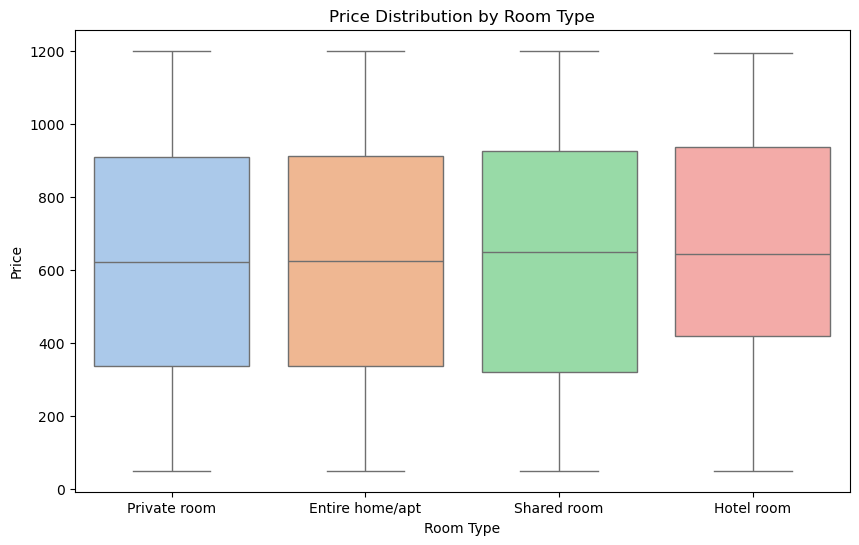

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', hue='room_type', data=df, palette='pastel', legend=False)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.title('Price Distribution by Room Type')
plt.show()

## Service fee and room price

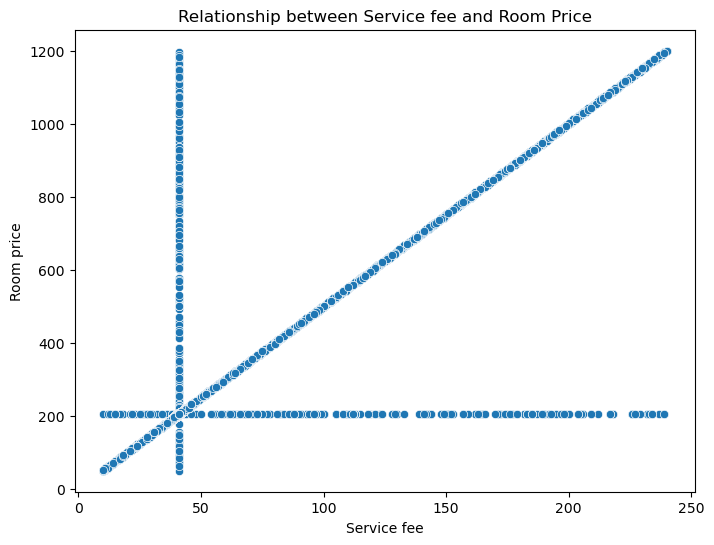

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='service_fee', y='price')
plt.xlabel('Service fee')
plt.ylabel('Room price')
plt.title('Relationship between Service fee and Room Price')
plt.show()

The scatter plot shows a positive correlation between service fee and room price.

## Listings available per year

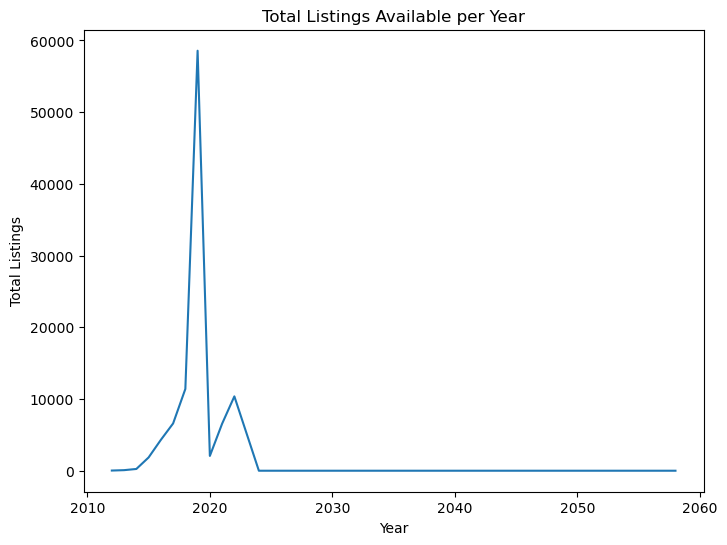

In [34]:
df['year'] = pd.to_datetime(df['last_review']).dt.year
listings_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.lineplot(x=listings_per_year.index, y=listings_per_year.values)
plt.xlabel('Year')
plt.ylabel('Total Listings')
plt.title('Total Listings Available per Year')
plt.show()

## Review rate number and price

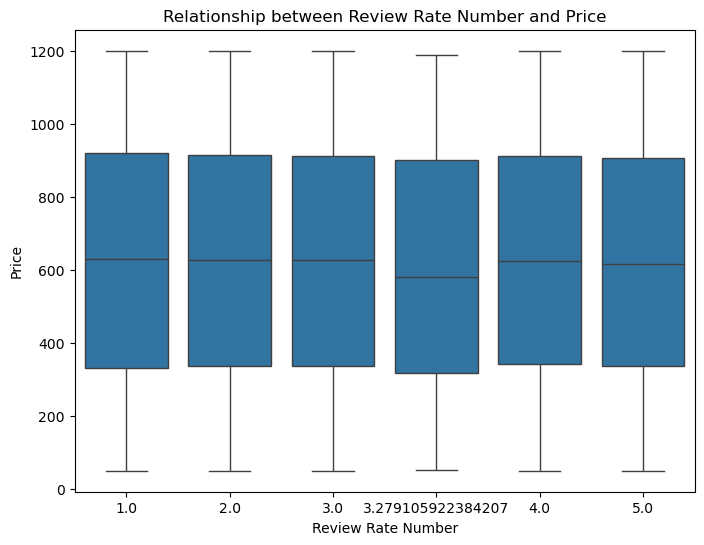

In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='review_rate_number', y='price')
plt.xlabel('Review Rate Number')
plt.ylabel('Price')
plt.title('Relationship between Review Rate Number and Price')
plt.show()

## Correlation analysis

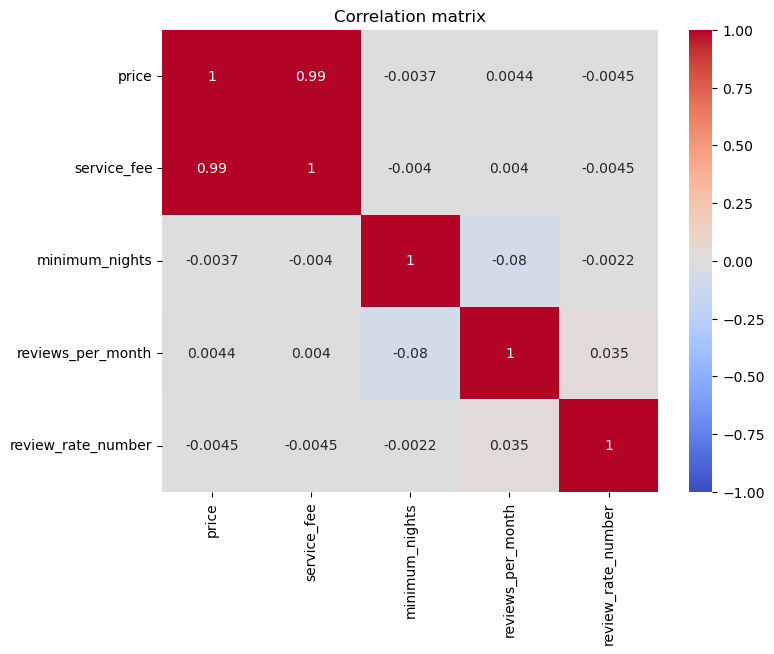

In [40]:
corr_cols = ['price', 'service_fee', 'minimum_nights', 'reviews_per_month', 'review_rate_number']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

## Price outlier analysis

In [38]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Outliers: {len(outliers)}")
print(f"Outlier percentage: {len(outliers) / len(df) * 100:.2f}%")

Outliers: 0
Outlier percentage: 0.00%


The outlier analysis returned no values outside the IQR threshold, so I focused on correlation and price distribution to better describe the dataset.

## Price distribution

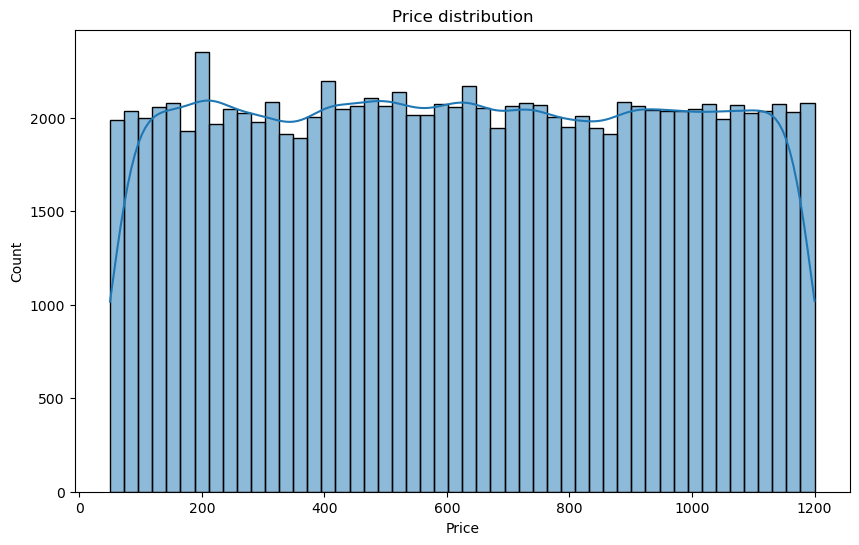

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

## Top neighbourhoods by listing count

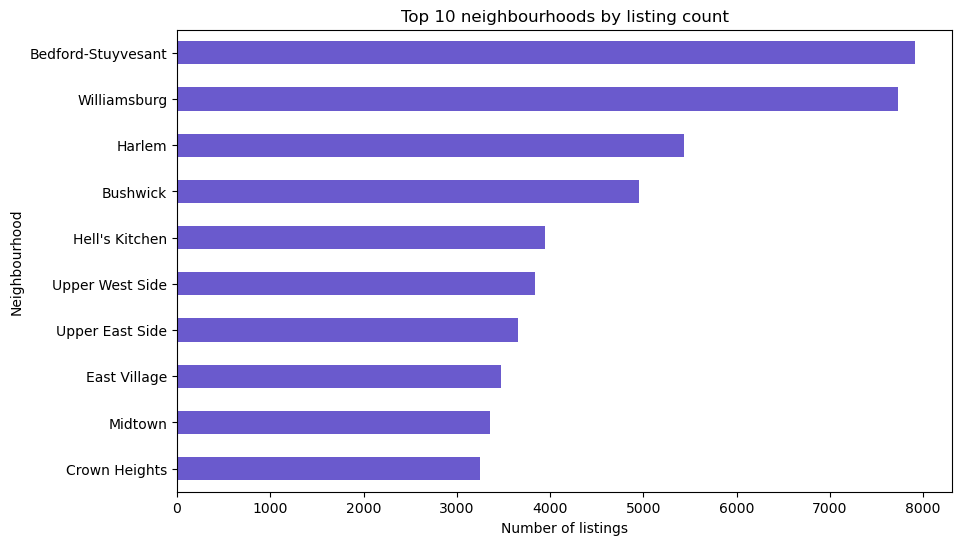

In [42]:
top_neigh = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_neigh.plot(kind='barh', color='slateblue')
plt.title('Top 10 neighbourhoods by listing count')
plt.xlabel('Number of listings')
plt.ylabel('Neighbourhood')
plt.gca().invert_yaxis()
plt.show()

## Conclusion
The Airbnb dataset shows a wide price variation across room types and neighbourhoods. The correlation heatmap helps identify relationships between the main numerical variables, while the outlier analysis shows that price values remain within the IQR threshold. Overall, the cleaned dataset provides a solid base for exploring pricing and listing patterns in New York City.